# Agroclimate Indicators Analysis (GDD, Heat Stress Days, Frost Days)
### Data Source: s3://water-insight-public-test/gdd_frost_heat_indicators/

---

## 📌 **Use Case: Monitoring Climate Risks for Agriculture**

This notebook analyzes key agroclimate metrics that directly impact U.S. crop production:

- **GDD (Growing Degree Days)** — crop development potential  
- **HSD (Heat Stress Days)** — crop heat risk  
- **Frost Days** — frost damage risk  

These metrics are **monthly gridded indicators** produced from NLDAS-3 daily forcing data.

**Use Case Example:**  
*A crop insurance analyst wants to identify regions experiencing increased heat stress or decreasing frost days, which affects planting schedules, crop insurance premiums, and risk outlooks.*

This notebook demonstrates:

✔️ Loading NetCDFs directly from S3  
✔️ Reading metadata, attributes, CRS, and coordinate structure  
✔️ Spatial subsetting  
✔️ Time stacking (convert monthly files into a multi-year dataset)  
✔️ Visualization on a map  
✔️ Time-series extraction for a point or region  
✔️ Compute trends / anomalies  

---

In [1]:
# 1. Setup
import xarray as xr
import fsspec
import s3fs
import hvplot.xarray
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import glob


In [2]:
fs = s3fs.S3FileSystem(anon=False)

bucket_path = "water-insight-public-test/gdd_frost_heat_indicators/"
files = fs.glob(bucket_path + "*.nc")

files[:12]

['water-insight-public-test/gdd_frost_heat_indicators/agroclim_indicator-200101.nc',
 'water-insight-public-test/gdd_frost_heat_indicators/agroclim_indicator-200102.nc',
 'water-insight-public-test/gdd_frost_heat_indicators/agroclim_indicator-200103.nc',
 'water-insight-public-test/gdd_frost_heat_indicators/agroclim_indicator-200104.nc',
 'water-insight-public-test/gdd_frost_heat_indicators/agroclim_indicator-200105.nc',
 'water-insight-public-test/gdd_frost_heat_indicators/agroclim_indicator-200106.nc',
 'water-insight-public-test/gdd_frost_heat_indicators/agroclim_indicator-200107.nc',
 'water-insight-public-test/gdd_frost_heat_indicators/agroclim_indicator-200108.nc',
 'water-insight-public-test/gdd_frost_heat_indicators/agroclim_indicator-200109.nc',
 'water-insight-public-test/gdd_frost_heat_indicators/agroclim_indicator-200110.nc',
 'water-insight-public-test/gdd_frost_heat_indicators/agroclim_indicator-200111.nc',
 'water-insight-public-test/gdd_frost_heat_indicators/agroclim_in

In [3]:
ds = xr.open_mfdataset(
    ["s3://" + f for f in files],
    engine="h5netcdf",
    combine="by_coords",
    parallel=True,
)

ds


<xarray.Dataset> Size: 252GB
Dimensions:     (time: 276, lat: 6500, lon: 11700)
Coordinates:
  * time        (time) datetime64[ns] 2kB 2001-01-01 2001-02-01 ... 2023-12-01
  * lon         (lon) float32 47kB -169.0 -169.0 -169.0 ... -52.03 -52.01 -52.0
  * lat         (lat) float32 26kB 7.005 7.015 7.025 7.035 ... 71.97 71.98 71.99
Data variables:
    gdd         (time, lat, lon) float32 84GB dask.array<chunksize=(1, 2167, 3900), meta=np.ndarray>
    hsd         (time, lat, lon) float32 84GB dask.array<chunksize=(1, 2167, 3900), meta=np.ndarray>
    frost_days  (time, lat, lon) float32 84GB dask.array<chunksize=(1, 2167, 3900), meta=np.ndarray>
Attributes:
    title:                    Monthly Climate Indicators for January 2001
    description:              Monthly Growing Degree Days, Heat Stress Days, ...
    source:                   NLDAS-3 daily meteorological data
    created:                  2025-08-23 13:37:07
    gdd_base_temperature:     10°C
    hsd_threshold:            30°C
    frost_threshold:          0°C
    conventions:              CF-1.6
    land_water_mask_applied:  True - values set to NaN where mask==0 (water) ...
    processing_method:        file_by_file_processing
    data_type_note:           All variables stored as float32 with NaN for oc...

In [4]:
print("Dimensions:", ds.dims)
print("Variables:", list(ds.data_vars))
print(ds.attrs)


Dimensions: FrozenMappingWarningOnValuesAccess({'time': 276, 'lat': 6500, 'lon': 11700})
Variables: ['gdd', 'hsd', 'frost_days']
{'title': 'Monthly Climate Indicators for January 2001', 'description': 'Monthly Growing Degree Days, Heat Stress Days, and Frost Days calculated from NLDAS-3 daily data', 'source': 'NLDAS-3 daily meteorological data', 'created': '2025-08-23 13:37:07', 'gdd_base_temperature': '10°C', 'hsd_threshold': '30°C', 'frost_threshold': '0°C', 'conventions': 'CF-1.6', 'land_water_mask_applied': 'True - values set to NaN where mask==0 (water) or mask==3 (no data)', 'processing_method': 'file_by_file_processing', 'data_type_note': 'All variables stored as float32 with NaN for ocean/water pixels'}


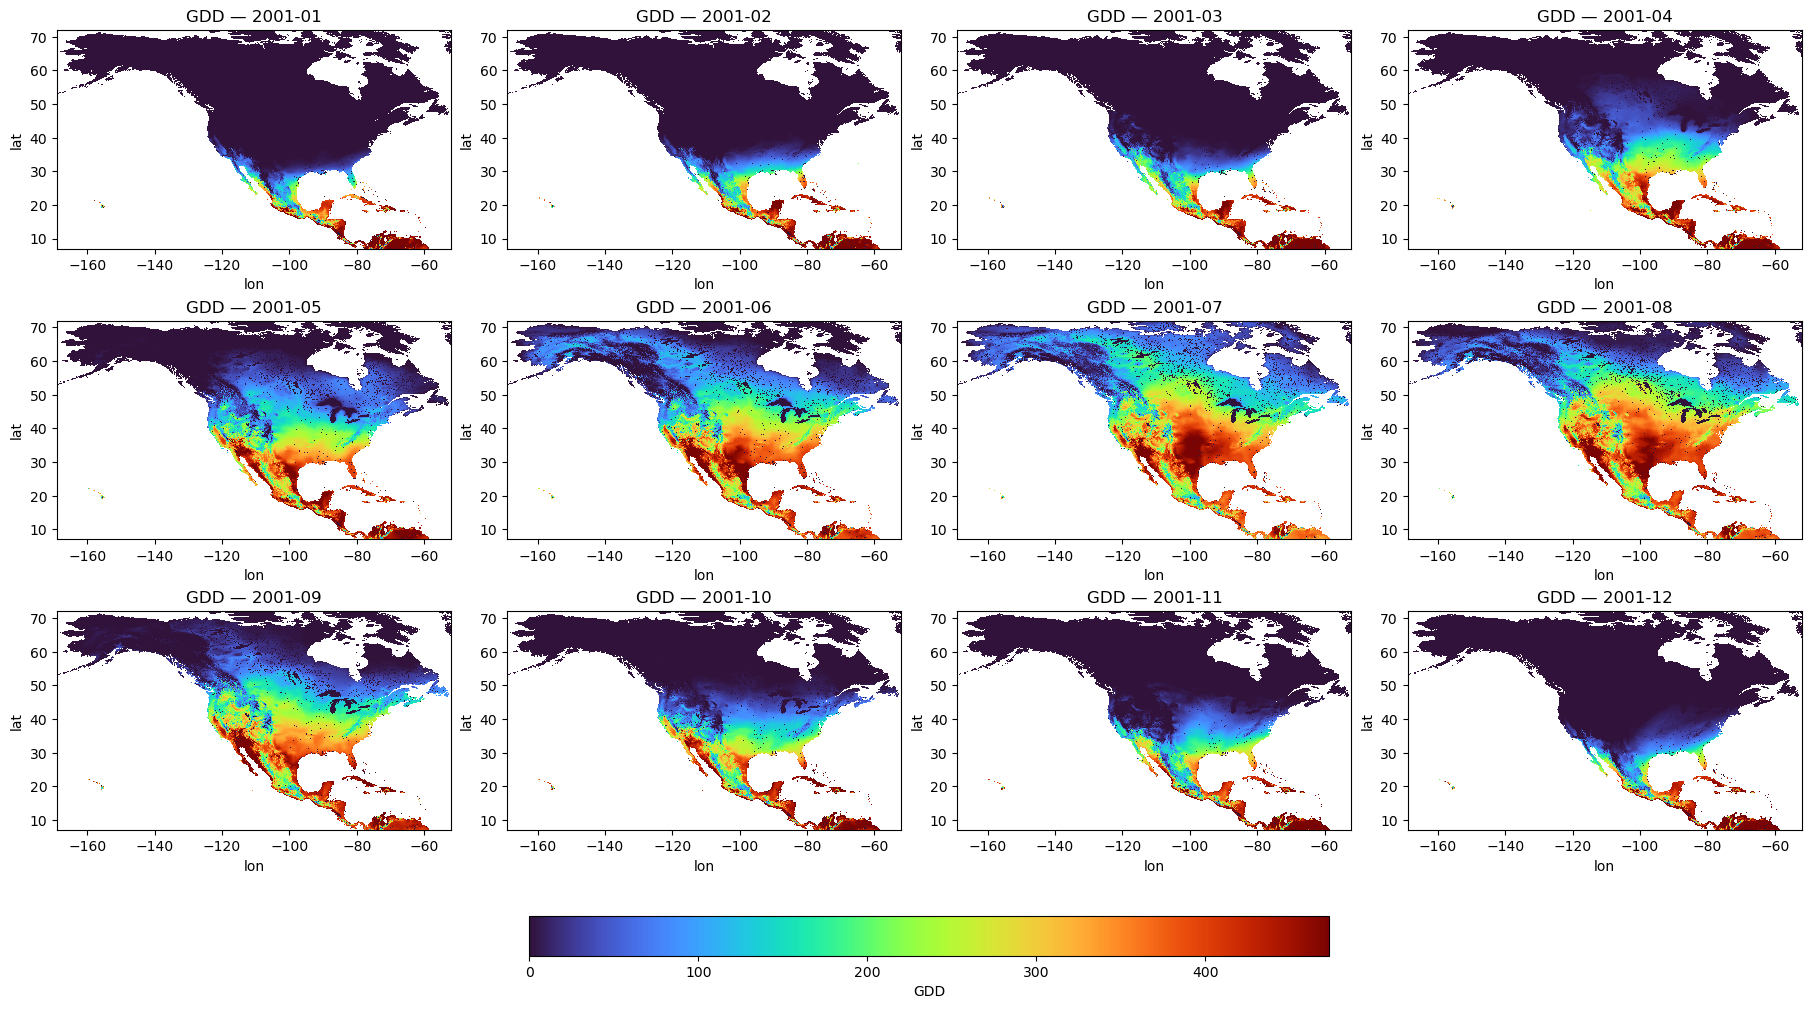

In [5]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(18, 10),
    constrained_layout=True
)

axes = axes.flatten()

for i in range(12):
    ds.gdd.isel(time=i).plot(
        ax=axes[i],
        cmap="turbo",
        robust=True,
        add_colorbar=False
    )

    month_str = ds.time.isel(time=i).dt.strftime("%Y-%m").item()
    axes[i].set_title(f"GDD — {month_str}")

# add ONE shared colorbar
cbar = fig.colorbar(
    axes[0].collections[0],
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.05
)
cbar.set_label("GDD")

plt.show()


In [ ]:
lat_pt = 41.6
lon_pt = -93.6

pt = ds.sel(
    lat=lat_pt,
    lon=lon_pt,
    method="nearest"
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 6),
    sharex=True
)

# Heat Stress Days
axes[0].plot(pt.time, pt.hsd)
axes[0].set_title("Heat Stress Days")
axes[0].set_ylabel("Days")
axes[0].grid(True)

# Frost Days
axes[1].plot(pt.time, pt.frost_days)
axes[1].set_title("Frost Days")
axes[1].set_ylabel("Days")
axes[1].grid(True)

axes[1].set_xlabel("Time")

fig.suptitle("Climate Indicators at Iowa Point", y=1.02)
plt.show()



In [6]:
np.random.seed(42)

# rough US bounding box
lat_min, lat_max = 25, 49
lon_min, lon_max = -125, -66

random_lats = np.random.uniform(lat_min, lat_max, 20)
random_lons = np.random.uniform(lon_min, lon_max, 20)

locations = list(zip(random_lats, random_lons))


In [ ]:
da = ds.gdd   # explicitly use GDD

ts_data = []

for i, (lat, lon) in enumerate(locations):
    ts = da.sel(
        lat=lat,
        lon=lon,
        method="nearest"
    )

    df = ts.to_dataframe(name="gdd").reset_index()
    df["location_id"] = i
    df["lat"] = lat
    df["lon"] = lon

    ts_data.append(df)

ts_df = pd.concat(ts_data, ignore_index=True)
ts_df.head()
